In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

X = pd.read_csv('../data/processed/X_feature.csv')
y = pd.read_csv('../data/processed/y_churn.csv')

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=84)

scaler = StandardScaler()
scaler.set_output(transform='pandas')
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [3]:
model_lr = LogisticRegression(class_weight='balanced')
model_lr.fit(X_train_scaled, y_train)
lr_predict = model_lr.predict(X_test_scaled)
lr_score = accuracy_score(y_test, lr_predict)
print(f"Logistics Scores: {lr_score:.3f}")
print("\nDetailed Report:\n", classification_report(y_test, lr_predict))
print(f"-> Model Coefficient {model_lr.coef_}")
cm = confusion_matrix(y_test, lr_predict)
print("\nThis is the Confusion Matrix\n", cm)

Logistics Scores: 0.921

Detailed Report:
               precision    recall  f1-score   support

         0.0       0.91      0.98      0.94      1194
         1.0       0.95      0.82      0.88       668

    accuracy                           0.92      1862
   macro avg       0.93      0.90      0.91      1862
weighted avg       0.92      0.92      0.92      1862

-> Model Coefficient [[-0.41926504 -0.02134962  0.00525688 -0.58727835  0.0772278  -0.063409
  -0.2384171   0.09595664  0.07108839  3.50656507]]

This is the Confusion Matrix
 [[1168   26]
 [ 122  546]]


c:\Users\HP\miniconda3\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [4]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)


xgb_model.fit(X_train_scaled, y_train)
xgb_predict = xgb_model.predict(X_test_scaled)
xgb_accuracy = accuracy_score(y_test, xgb_predict)
print(f"XGBoost Scores: {xgb_accuracy:.3f}")
print("\nDetailed Report:\n", classification_report(y_test, xgb_predict))
cm = confusion_matrix(y_test, xgb_predict)
print("\nThis is the Confusion Matrix\n", cm)

c:\Users\HP\miniconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:57:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Scores: 0.919

Detailed Report:
               precision    recall  f1-score   support

         0.0       0.90      0.98      0.94      1194
         1.0       0.95      0.81      0.88       668

    accuracy                           0.92      1862
   macro avg       0.93      0.90      0.91      1862
weighted avg       0.92      0.92      0.92      1862


This is the Confusion Matrix
 [[1168   26]
 [ 125  543]]


<Figure size 1000x600 with 0 Axes>

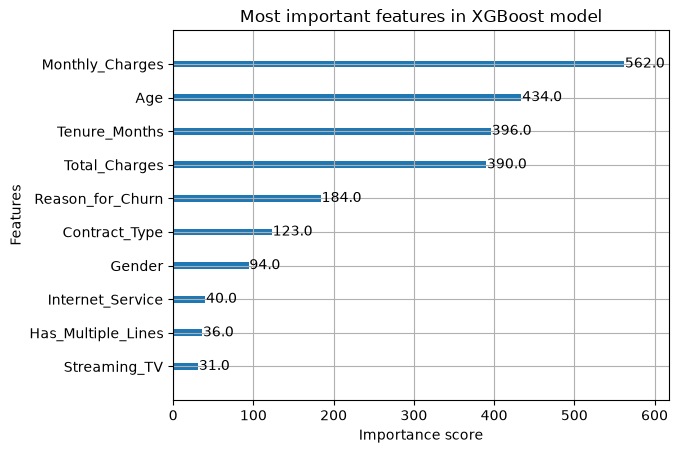

In [5]:
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, max_num_features=10, importance_type='weight')
plt.title("Most important features in XGBoost model")
plt.show()

In [6]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)

lgb_model.fit(X_train_scaled, y_train)
lgb_predict = lgb_model.predict(X_test_scaled)
lgb_score = accuracy_score(y_test, lgb_predict)

print(f"\nLightGBM Score: {lgb_score:.3f}")
print(f"\nDetailed Report:\n{classification_report(y_test, lgb_predict)}")
cm = confusion_matrix(y_test, lgb_predict)
print("This is the confusion matrix\n", cm)

c:\Users\HP\miniconda3\Lib\site-packages\sklearn\preprocessing\_label.py:103: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\preprocessing\_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)



LightGBM Score: 0.917

Detailed Report:
              precision    recall  f1-score   support

         0.0       0.90      0.98      0.94      1194
         1.0       0.95      0.81      0.88       668

    accuracy                           0.92      1862
   macro avg       0.93      0.89      0.91      1862
weighted avg       0.92      0.92      0.92      1862

This is the confusion matrix
 [[1168   26]
 [ 128  540]]


<Figure size 1000x600 with 0 Axes>

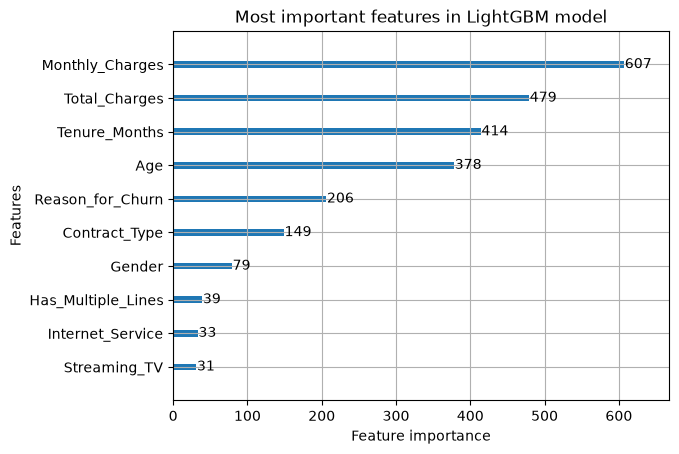

In [7]:
plt.figure(figsize=(10, 6))
lgb.plot_importance(lgb_model, max_num_features=10, importance_type='split')
plt.title("Most important features in LightGBM model")
plt.show()

In [8]:
xgb_param_dist = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': stats.uniform(0.01, 0.2),
    'subsample': stats.uniform(0.6, 0.4),
    'colsample_bytree': stats.uniform(0.6, 0.4),
    'min_child_weight': [1, 3, 5, 7]
}

xgb_base = xgb.XGBClassifier(
    use_label_encoder=False, eval_metric='logloss', random_state=42)

xgb_random = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=15,
    scoring='f1',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train_scaled, y_train)
best_xgb = xgb_random.best_estimator_
xgb_tuned_predict = best_xgb.predict(X_test_scaled)

xgb_tuned_accuracy = accuracy_score(y_test, xgb_tuned_predict)
print(f"Accuracy Score: {xgb_tuned_accuracy:.3f}")
print("\n--- Best XGBoost Parameter Found ---")
print(xgb_random.best_params_)
print("\n--- Tuned XGBoosp Performance ---")
print(classification_report(y_test, xgb_tuned_predict))
print(confusion_matrix(y_test, xgb_tuned_predict))

Fitting 5 folds for each of 15 candidates, totalling 75 fits


c:\Users\HP\miniconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:57:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy Score: 0.920

--- Best XGBoost Parameter Found ---
{'colsample_bytree': np.float64(0.8832290311184181), 'learning_rate': np.float64(0.014116898859160489), 'max_depth': 4, 'min_child_weight': 7, 'n_estimators': 250, 'subsample': np.float64(0.9754210836063001)}

--- Tuned XGBoosp Performance ---
              precision    recall  f1-score   support

         0.0       0.91      0.98      0.94      1194
         1.0       0.95      0.82      0.88       668

    accuracy                           0.92      1862
   macro avg       0.93      0.90      0.91      1862
weighted avg       0.92      0.92      0.92      1862

[[1167   27]
 [ 122  546]]


In [9]:
lgb_param_dist = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [3, 4, 5, 6, 7],
    'num_leaves': [15, 31, 63, 127],
    'learning_rate': stats.uniform(0.01, 0.2),
    'subsample': stats.uniform(0.6, 0.4),
    'colsample_bytree': stats.uniform(0.6, 0.4),
    'min_child_weight': [10, 20, 30, 50]
}

lgb_base = lgb.LGBMClassifier(verbosity=-1, random_state=42)

lgb_random = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=lgb_param_dist,
    n_iter=15,
    scoring='f1',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

lgb_random.fit(X_train_scaled, y_train)
best_lgb = lgb_random.best_estimator_
lgb_tuned_predict = best_lgb.predict(X_test_scaled)

lgb_tuned_accuracy = accuracy_score(y_test, lgb_tuned_predict)
print(f"Accuracy Score: {lgb_tuned_accuracy:.3f}")
print("\n--- Best LightGB Parameter Found ---")
print(lgb_random.best_params_)
print("\n--- Tuned LightGB Performance ---")
print(classification_report(y_test, lgb_tuned_predict))
print(confusion_matrix(y_test, lgb_tuned_predict))

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Accuracy Score: 0.921

--- Best LightGB Parameter Found ---
{'colsample_bytree': np.float64(0.662397808134481), 'learning_rate': np.float64(0.021616722433639893), 'max_depth': 7, 'min_child_weight': 50, 'n_estimators': 200, 'num_leaves': 31, 'subsample': np.float64(0.6225646316108401)}

--- Tuned LightGB Performance ---
              precision    recall  f1-score   support

         0.0       0.91      0.98      0.94      1194
         1.0       0.95      0.82      0.88       668

    accuracy                           0.92      1862
   macro avg       0.93      0.90      0.91      1862
weighted avg       0.92      0.92      0.92      1862

[[1167   27]
 [ 120  548]]


c:\Users\HP\miniconda3\Lib\site-packages\sklearn\preprocessing\_label.py:103: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\preprocessing\_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


In [10]:
ensemble_teams = [
    ('lr', model_lr),
    ('xgb', xgb_random.best_estimator_),
    ('lgb', lgb_random.best_estimator_)
]

voting_ensemble = VotingClassifier(
    estimators=ensemble_teams,
    voting='soft',
    n_jobs=-1
)

voting_ensemble.fit(X_train_scaled, y_train)

ensemble_predict = voting_ensemble.predict(X_test_scaled)
ensemble_accuracy = accuracy_score(y_test, ensemble_predict)

print(f"\nEnsemble Accuracy Score: {ensemble_accuracy:.3f}")
print("\n--- Ensemble Performance Report ---")
print(classification_report(y_test, ensemble_predict))
print("Confusion Matrix")
print(confusion_matrix(y_test, ensemble_predict))

c:\Users\HP\miniconda3\Lib\site-packages\sklearn\preprocessing\_label.py:103: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\preprocessing\_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)



Ensemble Accuracy Score: 0.921

--- Ensemble Performance Report ---
              precision    recall  f1-score   support

         0.0       0.91      0.98      0.94      1194
         1.0       0.95      0.82      0.88       668

    accuracy                           0.92      1862
   macro avg       0.93      0.90      0.91      1862
weighted avg       0.92      0.92      0.92      1862

Confusion Matrix
[[1167   27]
 [ 120  548]]


In [11]:
import os
import joblib

model_dir = "models"
os.makedirs(model_dir, exist_ok=True)
# Logistics Regression
joblib.dump(model_lr, os.path.join(
    model_dir, "baseline_logistic_regression.pkl"))

# Tuned XGBoost model
joblib.dump(xgb_random.best_estimator_, os.path.join(
    model_dir, "tuned_xgboost.pkl"))
# Tuned LightGBM model
joblib.dump(lgb_random.best_estimator_, os.path.join(
    model_dir, "tuned_lightgbm.pkl"))
# Scaler
joblib.dump(scaler, os.path.join(model_dir, "scaler.pkl"))
# Ensemble voting
joblib.dump(voting_ensemble, os.path.join(model_dir, "ensemble_voting.pkl"))

['models\\ensemble_voting.pkl']